# NDCI Comparison — Fall vs Spring

Compares `bayspec_results_fall/silver_ndci_utm.tif` and `bayspec_results_spring/silver_ndci_utm.tif`.

**Section 1:** Full NDCI distributions for each dataset.  
**Section 2:** Distributions restricted to the spatial overlap of the two footprints.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.crs import CRS

plt.rcParams['figure.dpi'] = 120

FALL_PATH   = 'bayspec_results_fall/silver_ndci_utm.tif'
SPRING_PATH = 'bayspec_results_spring/silver_ndci_utm.tif'

FALL_COLOR   = '#D4522A'
SPRING_COLOR = '#2A8D4F'
ALPHA = 0.6
N_BINS = 120

## 1. Load both NDCI rasters

In [2]:
def load_ndci(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        nodata = src.nodata
        profile = src.profile.copy()
        bounds  = src.bounds
        transform = src.transform
        crs = src.crs
    if nodata is not None:
        data[data == nodata] = np.nan
    return data, profile, bounds, transform, crs

fall_data,   fall_prof,   fall_bounds,   fall_tf,   fall_crs   = load_ndci(FALL_PATH)
spring_data, spring_prof, spring_bounds, spring_tf, spring_crs = load_ndci(SPRING_PATH)

def fmt_bounds(b): return f'W={b.left:.1f} E={b.right:.1f} S={b.bottom:.1f} N={b.top:.1f}'

print(f'Fall   shape: {fall_data.shape}   CRS: {fall_crs.to_epsg()}   bounds: {fmt_bounds(fall_bounds)}')
print(f'Spring shape: {spring_data.shape} CRS: {spring_crs.to_epsg()} bounds: {fmt_bounds(spring_bounds)}')
print(f'Fall   valid pixels: {np.isfinite(fall_data).sum():,}')
print(f'Spring valid pixels: {np.isfinite(spring_data).sum():,}')

Fall   shape: (288, 1191)   CRS: 32618   bounds: W=511610.8 E=511968.1 S=4440975.1 N=4441061.5
Spring shape: (253, 1212) CRS: 32618 bounds: W=511607.2 E=511970.8 S=4440984.9 N=4441060.8
Fall   valid pixels: 119,954
Spring valid pixels: 139,244


## 2. Full NDCI distributions

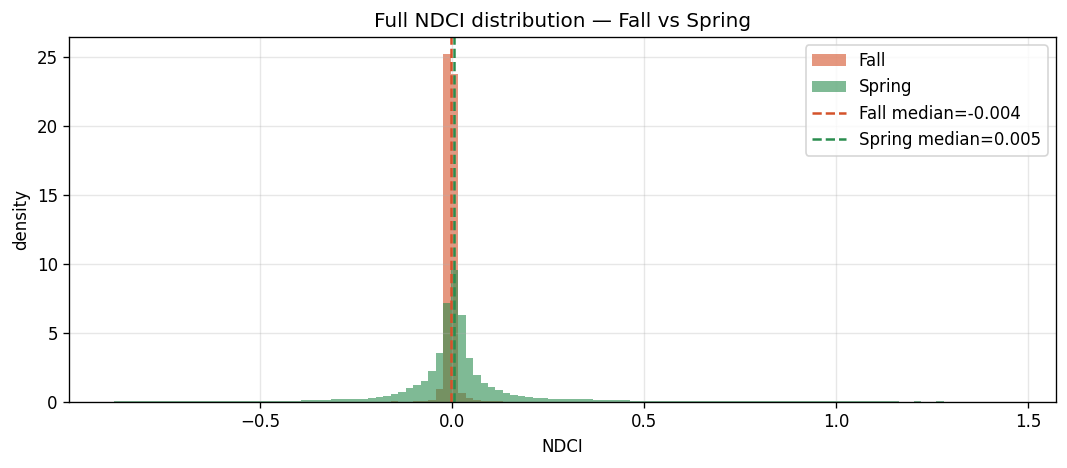

Fall   NDCI  mean=-0.0043  std=0.0393  median=-0.0036
Spring NDCI  mean=0.0212  std=1.8029  median=0.0051


In [3]:
fall_vals   = fall_data[np.isfinite(fall_data)].ravel()
spring_vals = spring_data[np.isfinite(spring_data)].ravel()

# shared bin range across both datasets
lo = min(np.percentile(fall_vals, 1), np.percentile(spring_vals, 1))
hi = max(np.percentile(fall_vals, 99), np.percentile(spring_vals, 99))
bins = np.linspace(lo, hi, N_BINS + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(fall_vals,   bins=bins, color=FALL_COLOR,   alpha=ALPHA, label='Fall',   density=True)
ax.hist(spring_vals, bins=bins, color=SPRING_COLOR, alpha=ALPHA, label='Spring', density=True)
ax.axvline(np.median(fall_vals),   color=FALL_COLOR,   lw=1.5, ls='--', label=f'Fall median={np.median(fall_vals):.3f}')
ax.axvline(np.median(spring_vals), color=SPRING_COLOR, lw=1.5, ls='--', label=f'Spring median={np.median(spring_vals):.3f}')
ax.set_xlabel('NDCI'); ax.set_ylabel('density')
ax.set_title('Full NDCI distribution — Fall vs Spring')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Fall   NDCI  mean={fall_vals.mean():.4f}  std={fall_vals.std():.4f}  median={np.median(fall_vals):.4f}')
print(f'Spring NDCI  mean={spring_vals.mean():.4f}  std={spring_vals.std():.4f}  median={np.median(spring_vals):.4f}')

## 3. Compute spatial overlap

Both rasters should share the same UTM CRS. We find the intersection of their geographic extents, then reproject the spring raster onto the fall raster's grid (within the overlap window) so pixel-for-pixel comparison is valid.

In [4]:
from rasterio.warp import transform_bounds
from rasterio.transform import from_bounds

# reproject spring bounds into fall CRS if needed
if spring_crs != fall_crs:
    sb = transform_bounds(spring_crs, fall_crs, *spring_bounds)
    sb = rasterio.coords.BoundingBox(*sb)
else:
    sb = spring_bounds

fb = fall_bounds

# intersection
left   = max(fb.left,   sb.left)
bottom = max(fb.bottom, sb.bottom)
right  = min(fb.right,  sb.right)
top    = min(fb.top,    sb.top)

if left >= right or bottom >= top:
    raise ValueError('Rasters do not overlap — check that both cover the same lake area.')

overlap_area_km2 = (right - left) * (top - bottom) / 1e6
print(f'Overlap extent: W={left:.1f} E={right:.1f} S={bottom:.1f} N={top:.1f}')
print(f'Overlap area:   {overlap_area_km2:.4f} km²')

Overlap extent: W=511610.8 E=511968.1 S=4440984.9 N=4441060.8
Overlap area:   0.0271 km²


In [5]:
from rasterio.windows import from_bounds as window_from_bounds

# Read fall pixels inside the overlap window (native resolution)
with rasterio.open(FALL_PATH) as src:
    win = window_from_bounds(left, bottom, right, top, src.transform)
    win = win.round_lengths().round_offsets()
    fall_overlap = src.read(1, window=win).astype(np.float32)
    fall_overlap_tf = src.window_transform(win)
    overlap_height = fall_overlap.shape[0]
    overlap_width  = fall_overlap.shape[1]
    if src.nodata is not None:
        fall_overlap[fall_overlap == src.nodata] = np.nan

print(f'Fall overlap window: {fall_overlap.shape}  valid: {np.isfinite(fall_overlap).sum():,}')

# Reproject spring onto the same grid as the fall overlap window
spring_overlap = np.full_like(fall_overlap, np.nan)

with rasterio.open(SPRING_PATH) as src:
    reproject(
        source=rasterio.band(src, 1),
        destination=spring_overlap,
        src_transform=spring_tf,
        src_crs=spring_crs,
        src_nodata=src.nodata,
        dst_transform=fall_overlap_tf,
        dst_crs=fall_crs,
        dst_nodata=np.nan,
        resampling=Resampling.bilinear
    )

print(f'Spring overlap window: {spring_overlap.shape}  valid: {np.isfinite(spring_overlap).sum():,}')

Fall overlap window: (253, 1191)  valid: 115,208
Spring overlap window: (253, 1191)  valid: 138,873


## 4. NDCI distributions within the overlap region

Co-located valid pixels (both datasets): 60,557


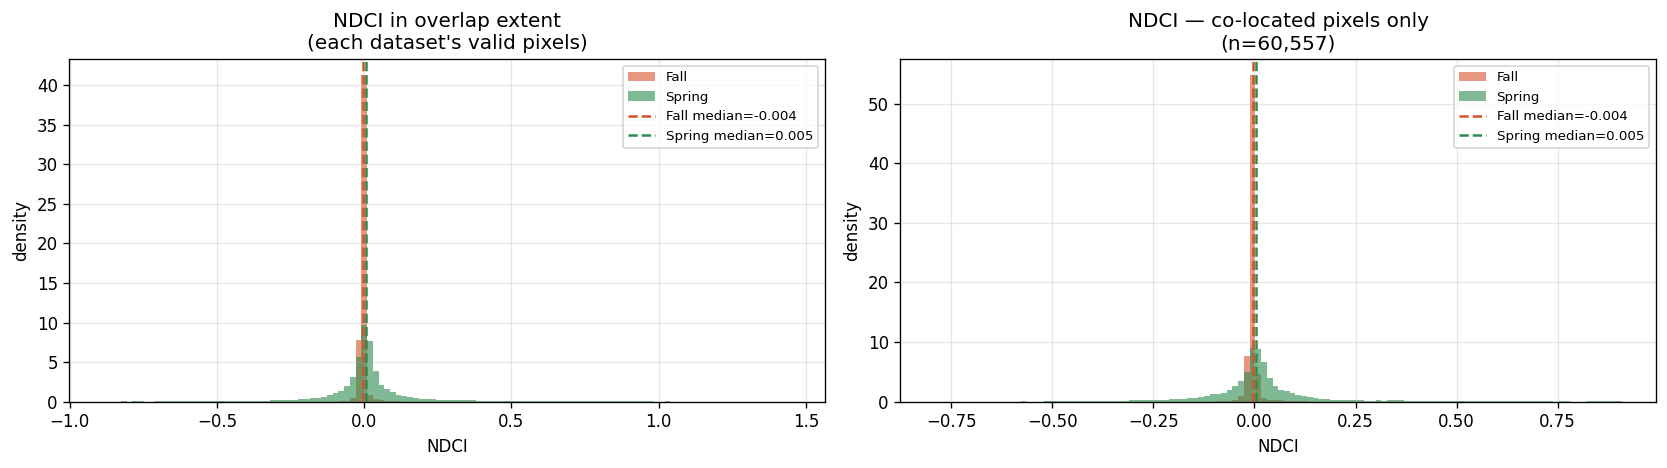

Co-located Fall   NDCI  mean=-0.0050  std=0.0537  median=-0.0040
Co-located Spring NDCI  mean=0.0061  std=0.9411  median=0.0049
Pixel-wise NDCI difference (fall - spring): mean=-0.0111  std=0.9427


In [6]:
# pixels where BOTH rasters have valid data
both_valid = np.isfinite(fall_overlap) & np.isfinite(spring_overlap)
print(f'Co-located valid pixels (both datasets): {both_valid.sum():,}')

# pixels where AT LEAST ONE raster has valid data (union of footprints within overlap box)
fall_ov_vals   = fall_overlap[np.isfinite(fall_overlap)].ravel()
spring_ov_vals = spring_overlap[np.isfinite(spring_overlap)].ravel()

lo2 = min(np.percentile(fall_ov_vals, 1),   np.percentile(spring_ov_vals, 1))   if len(fall_ov_vals) and len(spring_ov_vals) else lo
hi2 = max(np.percentile(fall_ov_vals, 99),  np.percentile(spring_ov_vals, 99))  if len(fall_ov_vals) and len(spring_ov_vals) else hi
bins2 = np.linspace(lo2, hi2, N_BINS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- left: each dataset's pixels that fall inside the overlap bounding box ---
ax = axes[0]
ax.hist(fall_ov_vals,   bins=bins2, color=FALL_COLOR,   alpha=ALPHA, label='Fall',   density=True)
ax.hist(spring_ov_vals, bins=bins2, color=SPRING_COLOR, alpha=ALPHA, label='Spring', density=True)
if len(fall_ov_vals):
    ax.axvline(np.median(fall_ov_vals),   color=FALL_COLOR,   lw=1.5, ls='--',
               label=f'Fall median={np.median(fall_ov_vals):.3f}')
if len(spring_ov_vals):
    ax.axvline(np.median(spring_ov_vals), color=SPRING_COLOR, lw=1.5, ls='--',
               label=f'Spring median={np.median(spring_ov_vals):.3f}')
ax.set_xlabel('NDCI'); ax.set_ylabel('density')
ax.set_title('NDCI in overlap extent\n(each dataset\'s valid pixels)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- right: only co-located pixels where BOTH are valid ---
ax = axes[1]
fall_co   = fall_overlap[both_valid].ravel()
spring_co = spring_overlap[both_valid].ravel()

if len(fall_co) == 0:
    ax.text(0.5, 0.5, 'No co-located pixels found', transform=ax.transAxes, ha='center')
else:
    lo3 = min(np.percentile(fall_co, 1), np.percentile(spring_co, 1))
    hi3 = max(np.percentile(fall_co, 99), np.percentile(spring_co, 99))
    bins3 = np.linspace(lo3, hi3, N_BINS + 1)
    ax.hist(fall_co,   bins=bins3, color=FALL_COLOR,   alpha=ALPHA, label='Fall',   density=True)
    ax.hist(spring_co, bins=bins3, color=SPRING_COLOR, alpha=ALPHA, label='Spring', density=True)
    ax.axvline(np.median(fall_co),   color=FALL_COLOR,   lw=1.5, ls='--',
               label=f'Fall median={np.median(fall_co):.3f}')
    ax.axvline(np.median(spring_co), color=SPRING_COLOR, lw=1.5, ls='--',
               label=f'Spring median={np.median(spring_co):.3f}')
    ax.set_xlabel('NDCI'); ax.set_ylabel('density')
    ax.set_title(f'NDCI — co-located pixels only\n(n={len(fall_co):,})')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

if len(fall_co):
    print(f'Co-located Fall   NDCI  mean={fall_co.mean():.4f}  std={fall_co.std():.4f}  median={np.median(fall_co):.4f}')
    print(f'Co-located Spring NDCI  mean={spring_co.mean():.4f}  std={spring_co.std():.4f}  median={np.median(spring_co):.4f}')
    print(f'Pixel-wise NDCI difference (fall - spring): mean={( fall_co - spring_co).mean():.4f}  std={(fall_co - spring_co).std():.4f}')

## 5. Spatial maps of the overlap area

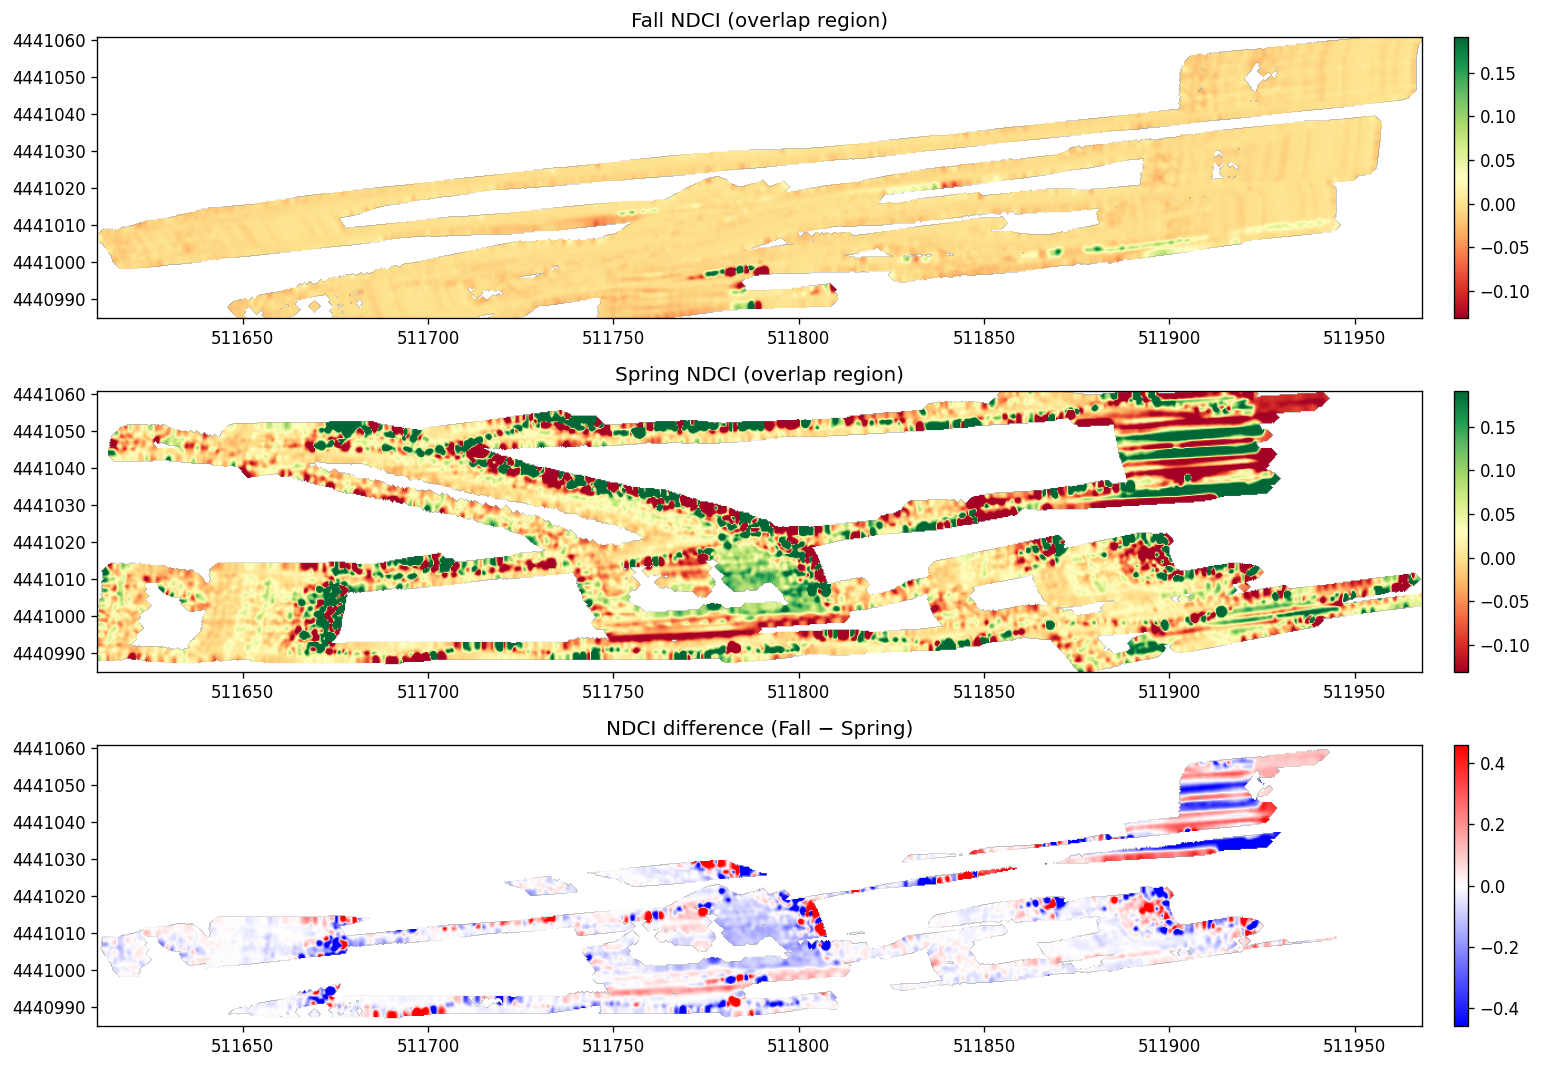

In [7]:
vmin = np.nanpercentile(np.concatenate([fall_overlap[np.isfinite(fall_overlap)],
                                         spring_overlap[np.isfinite(spring_overlap)]]), 5)
vmax = np.nanpercentile(np.concatenate([fall_overlap[np.isfinite(fall_overlap)],
                                         spring_overlap[np.isfinite(spring_overlap)]]), 95)

ext = [left, right, bottom, top]

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

im0 = axes[0].imshow(fall_overlap,   extent=ext, origin='upper', cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='equal')
axes[0].set_title('Fall NDCI (overlap region)'); axes[0].ticklabel_format(useOffset=False, style='plain')
plt.colorbar(im0, ax=axes[0], fraction=0.02, pad=0.02)

im1 = axes[1].imshow(spring_overlap, extent=ext, origin='upper', cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='equal')
axes[1].set_title('Spring NDCI (overlap region)'); axes[1].ticklabel_format(useOffset=False, style='plain')
plt.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.02)

diff = fall_overlap - spring_overlap
dlim = np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 95)
im2 = axes[2].imshow(diff, extent=ext, origin='upper', cmap='bwr', vmin=-dlim, vmax=dlim, aspect='equal')
axes[2].set_title('NDCI difference (Fall − Spring)'); axes[2].ticklabel_format(useOffset=False, style='plain')
plt.colorbar(im2, ax=axes[2], fraction=0.02, pad=0.02)

plt.tight_layout()
plt.show()